# Validazione del modello di siting — controprova e test del modello nullo

**Progetto EV Charge Desert** · provincia di Milano

---

Questo notebook fa due cose, in quest'ordine:

1. **Replica** la validazione a controprova già fatta nel progetto (§7 della metodologia):
   si spengono le colonnine reali, si chiede al modello dove metterle, si misura quanto
   ci va vicino.
2. **Mette alla prova la validazione stessa**: quei numeri vogliono davvero dire qualcosa?
   Per scoprirlo confrontiamo il modello con dei *baseline*, cioè con avversari stupidi.
   Se un avversario stupido ottiene lo stesso punteggio, il punteggio non misura la bravura
   del modello.

> **Il concetto chiave, in una frase.** Un numero da solo non dice niente. "Il modello sbaglia
> di 284 metri" è un'informazione utile solo se sappiamo di quanto sbaglierebbe qualcos'altro.
> Tutto questo notebook serve a costruire quel "qualcos'altro".

L'ultima sezione contiene il **testo pronto per la presentazione**.

## 0. Come far girare questo notebook

Servono cinque file, tutti già presenti nel progetto. Mettili in una cartella e indica
il percorso in `CARTELLA_DATI` nella cella qui sotto.

| File | Dove sta |
|---|---|
| `sezioni_target_validazione.geojson` | `Progetto4-Master/SCRIPT/` |
| `candidati_siting_provincia.csv` | `Progetto4-Master/SCRIPT/` |
| `validazione_controprova.csv` | `Progetto4-Master/SCRIPT/` |
| `poi_dati_target.csv` | `Progetto4-Master/SCRIPT/` |
| `pun_colonnine_pulito.csv` | cartella Drive `0_colonnine_ricarica` |

Librerie: `pandas numpy scipy shapely pyproj matplotlib`

```
pip install pandas numpy scipy shapely pyproj matplotlib
```

In [1]:
# ============================================================================
#  SETUP
# ============================================================================
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from shapely.geometry import shape, Point
from shapely.ops import transform as trasforma_geometria
from shapely import contains_xy               # versione vettoriale, molto piu veloce
from pyproj import Transformer
from scipy.spatial import cKDTree
from scipy.optimize import linear_sum_assignment
from scipy import stats

# >>> CAMBIA QUI SE I FILE STANNO ALTROVE <<<
CARTELLA_DATI = Path("dati")

# Seme fisso: rilanciando il notebook si ottengono gli stessi identici numeri.
SEME = 42
rng = np.random.default_rng(SEME)

# Quanti punti casuali estraiamo per sezione nei test (piu alto = piu stabile, piu lento)
N_ESTRAZIONI = 1000

# Le sezioni di censimento arrivano in gradi (lat/lon). Per misurare DISTANZE IN METRI
# vanno proiettate su un sistema metrico: UTM zona 32N, quello giusto per il Nord Italia.
# Senza questa conversione ogni distanza calcolata sarebbe sbagliata.
verso_metri = Transformer.from_crs("EPSG:4326", "EPSG:32632", always_xy=True).transform


# ---- funzioni di stampa, servono solo a rendere leggibili gli output ----
def titolo(t):
    print("\n" + "=" * 78)
    print("  " + t)
    print("=" * 78)

def nota(t):
    print("\n  >> " + t)

print("Setup completato.")

Setup completato.


## 1. Carichiamo i dati

Quattro ingredienti:

- **le sezioni di censimento** con la loro forma sulla mappa (i poligoni);
- **le colonnine reali** di tutta Italia, con le coordinate GPS;
- **i candidati del modello**, cioè i punti che il modello raccomanda (fino a 3 per sezione);
- **il risultato della validazione originale**, che useremo come pietra di paragone per
  verificare di aver ricostruito tutto correttamente.

In [2]:
# ---- 1a. Le sezioni di censimento (968: 818 critiche + 150 di controprova) ----
geo = json.load(open(CARTELLA_DATI / "sezioni_target_validazione.geojson"))

sezioni = {}
for elemento in geo["features"]:
    prop = elemento["properties"]
    sezioni[int(prop["SEZ2011"])] = {
        "info": prop,
        # la forma della sezione, gia convertita in metri
        "forma": trasforma_geometria(verso_metri, shape(elemento["geometry"])),
    }

titolo("1. DATI CARICATI")
print(f"  sezioni totali .................. {len(sezioni)}")
conteggio = pd.Series([s['info']['gruppo'] for s in sezioni.values()]).value_counts()
for gruppo, n in conteggio.items():
    print(f"    di cui '{gruppo}' ............ {n}")


  1. DATI CARICATI
  sezioni totali .................. 968
    di cui 'critica' ............ 818
    di cui 'controprova' ............ 150


In [3]:
# ---- 1b. Le colonnine reali ----
# Il file nazionale contiene 72.648 EVSE. Attenzione alla differenza:
#   EVSE  = singolo connettore (una colonnina con 4 prese conta 4 volte)
#   PUNTO = posizione fisica sulla mappa
# Per le distanze conta la POSIZIONE, quindi togliamo i duplicati sulle coordinate.
colonnine = pd.read_csv(
    CARTELLA_DATI / "pun_colonnine_pulito.csv",
    usecols=["evse_id", "status", "latitude", "longitude"],
)
n_italia = len(colonnine)

# Teniamo solo il riquadro attorno alla provincia di Milano: il resto d'Italia
# non serve e rallenterebbe tutti i calcoli.
in_zona = colonnine.latitude.between(45.1, 45.75) & colonnine.longitude.between(8.6, 9.65)
colonnine = colonnine[in_zona].copy()

x, y = verso_metri(colonnine.longitude.values, colonnine.latitude.values)
colonnine["x"], colonnine["y"] = x, y

evse_xy  = colonnine[["x", "y"]].to_numpy()                      # tutti i connettori
punti_xy = colonnine.drop_duplicates(["x", "y"])[["x", "y"]].to_numpy()  # posizioni fisiche

print(f"  EVSE in Italia ................. {n_italia:,}")
print(f"  EVSE nella zona di Milano ...... {len(colonnine):,}")
print(f"  posizioni fisiche distinte ..... {len(punti_xy):,}")
nota(f"in media {len(colonnine)/len(punti_xy):.1f} connettori per posizione fisica: "
     "un dettaglio che tornera utile piu avanti")

  EVSE in Italia ................. 72,648
  EVSE nella zona di Milano ...... 10,482
  posizioni fisiche distinte ..... 3,570

  >> in media 2.9 connettori per posizione fisica: un dettaglio che tornera utile piu avanti


In [4]:
# ---- 1c. I candidati del modello e la validazione originale ----
candidati = pd.read_csv(CARTELLA_DATI / "candidati_siting_provincia.csv")
cx, cy = verso_metri(candidati.lon.values, candidati.lat.values)
candidati["x"], candidati["y"] = cx, cy

controprova = candidati[candidati.gruppo == "controprova"].copy()
originale = pd.read_csv(CARTELLA_DATI / "validazione_controprova.csv")

print(f"  righe di candidati ............. {len(candidati)}")
print(f"  sezioni con almeno un candidato  {candidati.SEZ2011.nunique()} su 968 "
      f"({candidati.SEZ2011.nunique()/968*100:.1f}%)")
print(f"    di cui di controprova ........ {controprova.SEZ2011.nunique()} su 150")
print(f"  righe nella validazione originale {len(originale)}")
nota("il modello propone un punto solo per una sezione su tre: e il primo limite, "
     "e non dipende dalla validazione")

  righe di candidati ............. 665
  sezioni con almeno un candidato  345 su 968 (35.6%)
    di cui di controprova ........ 74 su 150
  righe nella validazione originale 74

  >> il modello propone un punto solo per una sezione su tre: e il primo limite, e non dipende dalla validazione


## 2. Ricostruiamo il campione da zero

Prima di criticare dei numeri bisogna essere sicuri di stare guardando gli stessi dati.

Ricostruiamo quindi **da capo** quali colonnine reali appartengono a ciascuna sezione,
usando la stessa regola del progetto: *una colonnina appartiene alla sezione se cade
entro 500 metri dal suo confine*.

Se il nostro conteggio coincide con il loro, siamo sicuri di aver capito il metodo.

In [5]:
titolo("2. RICOSTRUZIONE DEL CAMPIONE")

def colonnine_della_sezione(sez, solo_dentro=False):
    """Restituisce le posizioni delle colonnine reali associate a una sezione.

    solo_dentro=False -> quelle entro 500 m dal confine (regola del progetto)
    solo_dentro=True  -> solo quelle dentro il poligono (il controllo piu severo, §7.4)
    """
    forma = sezioni[int(sez)]["forma"]
    area = forma if solo_dentro else forma.buffer(500)
    # prefiltro veloce sul riquadro, poi test esatto
    x0, y0, x1, y1 = area.bounds
    sel = punti_xy[(punti_xy[:, 0] >= x0) & (punti_xy[:, 0] <= x1) &
                   (punti_xy[:, 1] >= y0) & (punti_xy[:, 1] <= y1)]
    if len(sel) == 0:
        return sel
    return sel[contains_xy(area, sel[:, 0], sel[:, 1])]


# verifica: contiamo gli EVSE (non le posizioni) per confrontarci col loro numero
verifica = []
for sez, loro_n in zip(originale.SEZ2011, originale.n_colonnine_reali_rimosse):
    area = sezioni[int(sez)]["forma"].buffer(500)
    x0, y0, x1, y1 = area.bounds
    sel = evse_xy[(evse_xy[:, 0] >= x0) & (evse_xy[:, 0] <= x1) &
                  (evse_xy[:, 1] >= y0) & (evse_xy[:, 1] <= y1)]
    mio_n = int(contains_xy(area, sel[:, 0], sel[:, 1]).sum())
    verifica.append((sez, loro_n, mio_n))

V = pd.DataFrame(verifica, columns=["SEZ2011", "loro", "nostro"])
uguali = (V.loro == V.nostro).sum()

print(f"  sezioni confrontate ............ {len(V)}")
print(f"  conteggi IDENTICI .............. {uguali} su {len(V)}")
nota("stiamo lavorando esattamente sugli stessi dati del progetto"
     if uguali == len(V) else "ATTENZIONE: qualcosa non torna")


  2. RICOSTRUZIONE DEL CAMPIONE
  sezioni confrontate ............ 74
  conteggi IDENTICI .............. 74 su 74

  >> stiamo lavorando esattamente sugli stessi dati del progetto


## 3. Ricalcoliamo il risultato del progetto

Per ogni sezione di controprova prendiamo **il primo punto in classifica** proposto dal
modello e misuriamo quanto dista dalla **colonnina reale più vicina**.

Una misura per sezione. Se il risultato coincide con `validazione_controprova.csv`,
la nostra ricostruzione è perfetta e possiamo andare avanti in sicurezza.

In [6]:
titolo("3. REPLICA DEL RISULTATO ORIGINALE")

replica = []
for sez in originale.SEZ2011:
    reali = colonnine_della_sezione(sez)
    if len(reali) == 0:
        continue
    albero = cKDTree(reali)
    punti_modello = controprova[controprova.SEZ2011 == sez].sort_values("rank")[["x", "y"]].to_numpy()
    distanze = albero.query(punti_modello)[0]
    replica.append({"SEZ2011": sez, "nostra_distanza": distanze[0]})

REP = pd.DataFrame(replica).merge(originale[["SEZ2011", "distanza_rank1_m"]], on="SEZ2011")
scarto = (REP.nostra_distanza - REP.distanza_rank1_m).abs().max()

print(f"  sezioni ricalcolate ............ {len(REP)}")
print(f"  scarto massimo dal loro valore   {scarto:.2f} metri")
nota("replica perfetta" if scarto < 0.5 else "c'e uno scostamento, da indagare")


  3. REPLICA DEL RISULTATO ORIGINALE
  sezioni ricalcolate ............ 74
  scarto massimo dal loro valore   0.05 metri

  >> replica perfetta


## 4. Costruiamo gli avversari (i *baseline*)

Ora la parte nuova. Confrontiamo il modello con tre alternative:

| Avversario | Cosa fa | Perché lo usiamo |
|---|---|---|
| **Punto a caso** | tira un punto a caso dentro la sezione, 1.000 volte | è l'avversario più stupido possibile: non sa cosa sia un parcheggio, può cadere in un campo o su un tetto. Se il modello non batte questo, è finita |
| **Centroide** | mette il punto esattamente al centro della sezione | zero intelligenza, zero dati, una riga di codice |
| **Candidato a caso** | prende uno dei 3 candidati del modello, ma a sorte | isola il contributo del *ranking* da traffico: stessi punti, ordine casuale |

Calcoliamo anche il **matching uno-a-uno** (algoritmo ungherese): invece di premiare il
punto perché è vicino a *una qualsiasi* delle N colonnine, obbliga ogni punto raccomandato
ad accoppiarsi con una colonnina diversa. Serve a controllare che il risultato non sia
gonfiato dal fatto che in certe sezioni di colonnine ce ne sono tantissime.

> ⏱️ Questa cella è la più lenta (circa un minuto): estrae 74.000 punti casuali.

In [7]:
titolo("4. CALCOLO DEI BASELINE  (puo richiedere ~1 minuto)")

def punti_a_caso(forma, quanti):
    """Estrae 'quanti' punti a caso uniformemente dentro il poligono.

    Metodo: si estrae dentro il rettangolo che contiene la forma e si scartano
    i punti fuori, finche non se ne hanno abbastanza."""
    x0, y0, x1, y1 = forma.bounds
    raccolti = []
    while sum(len(b) for b in raccolti) < quanti:
        xs = rng.uniform(x0, x1, quanti * 3)
        ys = rng.uniform(y0, y1, quanti * 3)
        dentro = contains_xy(forma, xs, ys)
        raccolti.append(np.column_stack([xs[dentro], ys[dentro]]))
    return np.vstack(raccolti)[:quanti]


righe = []
for sez in originale.SEZ2011:
    forma = sezioni[int(sez)]["forma"]
    reali = colonnine_della_sezione(sez)
    if len(reali) == 0:
        continue
    albero = cKDTree(reali)

    # --- il modello ---
    punti_modello = controprova[controprova.SEZ2011 == sez].sort_values("rank")[["x", "y"]].to_numpy()
    dist_per_rank = albero.query(punti_modello)[0]

    # --- avversario 1: punto a caso ---
    casuali = punti_a_caso(forma, N_ESTRAZIONI)
    dist_casuali = albero.query(casuali)[0]

    # --- avversario 2: centroide ---
    dist_centroide = albero.query([[forma.centroid.x, forma.centroid.y]])[0][0]

    # --- matching uno-a-uno ---
    costo = np.linalg.norm(punti_modello[:, None, :] - reali[None, :, :], axis=2)
    ri, ci = linear_sum_assignment(costo)

    # --- quanta parte della sezione "vincerebbe" comunque, a varie soglie ---
    campione_area = casuali[:600]
    dist_area = albero.query(campione_area)[0]

    righe.append({
        "SEZ2011": sez,
        "comune": sezioni[int(sez)]["info"]["COMUNE"],
        "n_candidati": len(punti_modello),
        "n_colonnine": len(reali),
        "modello": dist_per_rank[0],                  # il punto raccomandato
        "oracolo_top3": dist_per_rank.min(),          # il migliore dei 3 (usa la risposta!)
        "candidato_a_caso": dist_per_rank.mean(),     # media = valore atteso di una scelta a sorte
        "punto_a_caso": np.median(dist_casuali),
        "centroide": dist_centroide,
        "matching_1a1": costo[ri, ci].mean(),
        "quota_casuali_migliori": (dist_casuali < dist_per_rank[0]).mean(),
        "area_entro_100": (dist_area <= 100).mean(),
        "area_entro_250": (dist_area <= 250).mean(),
        "area_entro_500": (dist_area <= 500).mean(),
        "diametro_m": max(forma.bounds[2] - forma.bounds[0], forma.bounds[3] - forma.bounds[1]),
    })

D = pd.DataFrame(righe)
print(f"  sezioni analizzate ............. {len(D)}")
print(f"  punti casuali estratti ......... {len(D) * N_ESTRAZIONI:,}")
nota("fatto")


  4. CALCOLO DEI BASELINE  (puo richiedere ~1 minuto)


  sezioni analizzate ............. 74
  punti casuali estratti ......... 74,000

  >> fatto


## 5. Il confronto principale

Ecco il cuore di tutto. Per ogni concorrente: l'errore tipico (mediana) e la percentuale
di sezioni in cui è finito entro 100, 250 e 500 metri dalla colonnina reale.

**Come si legge:** più i numeri del modello si avvicinano a quelli del "punto a caso",
meno il modello sta dimostrando di saper fare qualcosa.

In [8]:
titolo("5. MODELLO CONTRO BASELINE")

def intervallo(valori, n=4000):
    """Intervallo di confidenza al 95% sulla mediana, calcolato con bootstrap.
    Dice: 'se rifacessimo lo studio, la mediana cadrebbe quasi sempre in questo range'."""
    v = np.asarray(valori)
    campioni = [np.median(rng.choice(v, len(v))) for _ in range(n)]
    return np.percentile(campioni, [2.5, 97.5])

concorrenti = [
    ("MODELLO (punto raccomandato)", "modello"),
    ("Punto a CASO nella sezione",   "punto_a_caso"),
    ("CENTROIDE della sezione",      "centroide"),
    ("Un candidato del modello a sorte", "candidato_a_caso"),
    ("Migliore dei primi 3 (*)",     "oracolo_top3"),
]

print(f"\n  {'':34s}{'mediana':>9s}{'IC 95%':>17s}{'<100m':>8s}{'<250m':>8s}{'<500m':>8s}")
print("  " + "-" * 84)
for etichetta, colonna in concorrenti:
    lo, hi = intervallo(D[colonna])
    p100 = (D[colonna] <= 100).mean() * 100
    p250 = (D[colonna] <= 250).mean() * 100
    p500 = (D[colonna] <= 500).mean() * 100
    print(f"  {etichetta:34s}{D[colonna].median():7.0f}m  [{lo:4.0f},{hi:4.0f}]m{p100:7.0f}%{p250:7.0f}%{p500:7.0f}%")

print("\n  (*) non e una vera prestazione: per sapere quale dei 3 e il migliore")
print("      bisogna gia conoscere la risposta. Va tolto dalle slide.")

nota(f"il modello sta a {D.modello.median():.0f}m, il punto a caso a {D.punto_a_caso.median():.0f}m, "
     f"il centroide a {D.centroide.median():.0f}m")


  5. MODELLO CONTRO BASELINE

                                      mediana           IC 95%   <100m   <250m   <500m
  ------------------------------------------------------------------------------------


  MODELLO (punto raccomandato)          284m  [ 252, 346]m     14%     38%     86%


  Punto a CASO nella sezione            278m  [ 253, 327]m      1%     38%     81%


  CENTROIDE della sezione               267m  [ 235, 320]m      7%     45%     85%


  Un candidato del modello a sorte      260m  [ 210, 360]m     11%     47%     88%


  Migliore dei primi 3 (*)              233m  [ 175, 300]m     22%     53%     91%

  (*) non e una vera prestazione: per sapere quale dei 3 e il migliore
      bisogna gia conoscere la risposta. Va tolto dalle slide.

  >> il modello sta a 284m, il punto a caso a 278m, il centroide a 267m


In [9]:
titolo("5b. I TEST STATISTICI")

print("""
  Come si legge il 'p'. E la probabilita di vedere una differenza cosi grande
  PER PURO CASO, se in realta i due metodi fossero equivalenti.
     p piccolo (< 0,05) -> la differenza e reale
     p grande           -> non c'e prova di alcuna differenza
""")

confronti = [
    ("Modello  vs  punto a caso",        "punto_a_caso"),
    ("Modello  vs  centroide",           "centroide"),
    ("Modello  vs  suo candidato a sorte", "candidato_a_caso"),
]

print(f"  {'':38s}{'differenza':>12s}{'vince il':>10s}{'p':>10s}   esito")
print("  " + "-" * 88)
for etichetta, colonna in confronti:
    diff = (D.modello - D[colonna]).mean()
    vince = (D.modello < D[colonna]).mean() * 100
    p = stats.wilcoxon(D.modello, D[colonna]).pvalue
    esito = "differenza reale" if p < 0.05 else "nessuna differenza dimostrabile"
    print(f"  {etichetta:38s}{diff:+9.0f} m{vince:9.0f}%{p:10.3f}   {esito}")

quota = D.quota_casuali_migliori.mean() * 100
peggio = (D.modello > D.punto_a_caso).sum()
print(f"\n  Un punto tirato a caso batte il modello nel {quota:.0f}% dei tiri.")
print(f"  In {peggio} sezioni su {len(D)} il punto casuale tipico e piu vicino della raccomandazione.")
nota("se il modello avesse un vero segnale, quella percentuale dovrebbe essere molto sotto il 50%")


  5b. I TEST STATISTICI

  Come si legge il 'p'. E la probabilita di vedere una differenza cosi grande
  PER PURO CASO, se in realta i due metodi fossero equivalenti.
     p piccolo (< 0,05) -> la differenza e reale
     p grande           -> non c'e prova di alcuna differenza

                                          differenza  vince il         p   esito
  ----------------------------------------------------------------------------------------
  Modello  vs  punto a caso                   -22 m       54%     0.138   nessuna differenza dimostrabile
  Modello  vs  centroide                       -8 m       51%     0.630   nessuna differenza dimostrabile
  Modello  vs  suo candidato a sorte           -1 m       30%     0.717   nessuna differenza dimostrabile

  Un punto tirato a caso batte il modello nel 46% dei tiri.
  In 34 sezioni su 74 il punto casuale tipico e piu vicino della raccomandazione.

  >> se il modello avesse un vero segnale, quella percentuale dovrebbe essere molto so

## 6. Perché "86% entro 500 metri" non dimostra niente

Qui c'è il nocciolo del problema, ed è **geometria**, non statistica.

Due fatti si sommano:

1. una sezione di censimento è larga circa 500 metri — cioè **quanto la soglia stessa**;
2. una colonnina entra nel conteggio solo se sta entro 500 metri dal confine — quindi
   la risposta giusta è già lì vicino **per costruzione**.

Risultato: in molte sezioni **qualunque** punto sta entro 500 metri da una colonnina.
Il test non può fallire, quindi non può nemmeno promuovere.

Misuriamolo: quanta parte dell'area di ogni sezione "vincerebbe" comunque?

In [10]:
titolo("6. LA TAUTOLOGIA GEOMETRICA")

print(f"\n  {'soglia':>8s}{'area della sezione che qualifica':>36s}{'risultato del modello':>24s}")
print("  " + "-" * 70)
for soglia in (100, 250, 500):
    area = D[f"area_entro_{soglia}"].mean() * 100
    mod = (D.modello <= soglia).mean() * 100
    print(f"  {soglia:6d} m{area:33.1f} %{mod:23.0f} %")

sempre = (D.area_entro_500 > 0.99).sum()
print(f"\n  Sezioni in cui OGNI punto sta entro 500 m da una colonnina: {sempre} su {len(D)}")
print(f"  Larghezza tipica di una sezione: {D.diametro_m.median():.0f} metri")

nota(f"in {sempre} sezioni non esiste una risposta sbagliata: la soglia dei 500 m "
     "e grande quanto tutta l'area in cui stiamo cercando")

print(f"\n  Controprova sul 'piu vicina fra N':")
print(f"    metrica usata nel report (la piu vicina fra tutte) : {D.modello.median():.0f} m")
print(f"    matching uno-a-uno (ogni punto accoppiato a una)   : {D.matching_1a1.median():.0f} m")
nota("differenza piccola: questo artefatto NON e il problema principale, la geometria si")


  6. LA TAUTOLOGIA GEOMETRICA

    soglia    area della sezione che qualifica   risultato del modello
  ----------------------------------------------------------------------
     100 m                              9.3 %                     14 %
     250 m                             40.4 %                     38 %
     500 m                             82.6 %                     86 %

  Sezioni in cui OGNI punto sta entro 500 m da una colonnina: 42 su 74
  Larghezza tipica di una sezione: 511 metri

  >> in 42 sezioni non esiste una risposta sbagliata: la soglia dei 500 m e grande quanto tutta l'area in cui stiamo cercando

  Controprova sul 'piu vicina fra N':
    metrica usata nel report (la piu vicina fra tutte) : 284 m
    matching uno-a-uno (ogni punto accoppiato a una)   : 277 m

  >> differenza piccola: questo artefatto NON e il problema principale, la geometria si


## 7. Il test più severo: solo le colonnine dentro il confine

Il buffer di 500 metri "regala" molto. Rifacciamo tutto guardando **solo le colonnine
che cadono davvero dentro il poligono** della sezione — è la stessa restrizione del §7.4
della metodologia, e riguarda 20 sezioni.

Qui l'aiuto della geometria si riduce parecchio, quindi è il confronto più informativo.

In [11]:
titolo("7. SOLO COLONNINE DENTRO IL CONFINE ESATTO")

dentro = []
for sez in D.SEZ2011:
    reali = colonnine_della_sezione(sez, solo_dentro=True)
    if len(reali) == 0:
        continue
    forma = sezioni[int(sez)]["forma"]
    albero = cKDTree(reali)
    punti_modello = controprova[controprova.SEZ2011 == sez].sort_values("rank")[["x", "y"]].to_numpy()
    casuali = punti_a_caso(forma, N_ESTRAZIONI)
    dentro.append({
        "SEZ2011": sez,
        "comune": sezioni[int(sez)]["info"]["COMUNE"],
        "n_colonnine_dentro": len(reali),
        "modello": albero.query(punti_modello)[0][0],
        "punto_a_caso": np.median(albero.query(casuali)[0]),
    })

DEN = pd.DataFrame(dentro)
p = stats.wilcoxon(DEN.modello, DEN.punto_a_caso).pvalue

print(f"  sezioni con colonnine dentro il confine: {len(DEN)}")
print(f"\n    modello ........ mediana {DEN.modello.median():6.0f} m   media {DEN.modello.mean():6.0f} m")
print(f"    punto a caso ... mediana {DEN.punto_a_caso.median():6.0f} m   media {DEN.punto_a_caso.mean():6.0f} m")
print(f"\n    differenza media: {(DEN.modello - DEN.punto_a_caso).mean():+.0f} m")
print(f"    il modello vince in {(DEN.modello < DEN.punto_a_caso).mean()*100:.0f}% delle sezioni   (p = {p:.3f})")
nota("nel confronto piu pulito il modello non e migliore del caso")

print("\n  Le 5 sezioni dove il modello va meglio:")
print(DEN.nsmallest(5, "modello")[["comune", "n_colonnine_dentro", "modello", "punto_a_caso"]]
      .round(0).to_string(index=False))


  7. SOLO COLONNINE DENTRO IL CONFINE ESATTO


  sezioni con colonnine dentro il confine: 20

    modello ........ mediana    244 m   media    236 m
    punto a caso ... mediana    219 m   media    225 m

    differenza media: +11 m
    il modello vince in 40% delle sezioni   (p = 0.674)

  >> nel confronto piu pulito il modello non e migliore del caso

  Le 5 sezioni dove il modello va meglio:
        comune  n_colonnine_dentro  modello  punto_a_caso
   Calvignasco                   2      6.0         151.0
        Solaro                   2     32.0         122.0
      Carpiano                   1     33.0         253.0
Pieve Emanuele                   1     39.0         391.0
        Milano                   1     74.0         119.0


## 8. Il ruolo del traffico

Il traffico entra nel modello in due punti soltanto:

- **come filtro**: una sezione riceve candidati solo se c'è un tratto di strada affidabile
  (≥5 letture) entro 300 m da un POI;
- **come classifica**: ordina i POI candidati dentro la stessa sezione.

Vediamo cosa fa davvero, e affrontiamo il dubbio legittimo: *la raccolta è stata fatta il
3-4 agosto, un periodo di traffico ridotto. Può essere quello il problema?*

In [12]:
titolo("8a. LA FORMULA DEL PUNTEGGIO")

# Ipotesi: punteggio = congestione x (1 - distanza/300), cioe il peso cala
# linearmente con la distanza e si azzera oltre i 300 m.
ipotesi = candidati.congestione_segmento_top * (1 - candidati.distanza_segmento_top_m / 300)
corr = np.corrcoef(ipotesi, candidati.punteggio_traffico)[0, 1]

print(f"  punteggio_traffico = congestione x (1 - distanza/300)")
print(f"  corrispondenza con i valori del file: r = {corr:.4f}")
nota("formula ricostruita esattamente: sappiamo con certezza cosa calcola il modello")

esempio = candidati[candidati.SEZ2011 == 151660000118][
    ["rank", "nome", "distanza_segmento_top_m", "congestione_segmento_top", "punteggio_traffico"]]
print("\n  Esempio (Paderno Dugnano, sezione 151660000118):")
print(esempio.to_string(index=False))
nota("stessa congestione per entrambi -> si semplifica -> vince chi e piu vicino alla strada")


  8a. LA FORMULA DEL PUNTEGGIO
  punteggio_traffico = congestione x (1 - distanza/300)
  corrispondenza con i valori del file: r = 1.0000

  >> formula ricostruita esattamente: sappiamo con certezza cosa calcola il modello

  Esempio (Paderno Dugnano, sezione 151660000118):
 rank         nome  distanza_segmento_top_m  congestione_segmento_top  punteggio_traffico
    1   Lady Pizza                     54.1                     0.189              0.1549
    2 I Love Cofeé                    199.9                     0.189              0.0631

  >> stessa congestione per entrambi -> si semplifica -> vince chi e piu vicino alla strada


In [13]:
titolo("8b. LA CLASSIFICA E DAVVERO GUIDATA DAL TRAFFICO?")

con_piu_candidati = candidati.groupby("SEZ2011").filter(lambda g: len(g) > 1)
valori_diversi = con_piu_candidati.groupby("SEZ2011").congestione_segmento_top.nunique()
stessa = (valori_diversi == 1).sum()

print(f"  sezioni con piu di un candidato ...................... {len(valori_diversi)}")
print(f"  in cui TUTTI i candidati guardano la stessa strada ... {stessa} ({stessa/len(valori_diversi)*100:.0f}%)")
nota("in quei casi la congestione e identica per tutti, si semplifica, "
     "e la classifica diventa solo 'chi e piu vicino a quella strada'")

primi = controprova[controprova["rank"] == 1].merge(D[["SEZ2011", "modello"]], on="SEZ2011")
print("\n  Il punteggio prevede l'errore reale?")
for colonna, etichetta in [("punteggio_traffico", "punteggio di traffico"),
                           ("congestione_segmento_top", "congestione della strada"),
                           ("n_letture_segmento_top", "numero di letture")]:
    rho, pv = stats.spearmanr(primi[colonna], primi.modello)
    print(f"    {etichetta:26s} correlazione {rho:+.2f}   p = {pv:.2f}")
nota("correlazioni vicine a zero e p alti: il punteggio non dice quanto ci si puo fidare")


  8b. LA CLASSIFICA E DAVVERO GUIDATA DAL TRAFFICO?
  sezioni con piu di un candidato ...................... 207
  in cui TUTTI i candidati guardano la stessa strada ... 129 (62%)

  >> in quei casi la congestione e identica per tutti, si semplifica, e la classifica diventa solo 'chi e piu vicino a quella strada'

  Il punteggio prevede l'errore reale?
    punteggio di traffico      correlazione -0.12   p = 0.32
    congestione della strada   correlazione -0.10   p = 0.40
    numero di letture          correlazione +0.11   p = 0.37

  >> correlazioni vicine a zero e p alti: il punteggio non dice quanto ci si puo fidare


In [14]:
titolo("8c. E COLPA DI AGOSTO?")

cg = candidati.congestione_segmento_top
print("  Congestione misurata (0 = strada libera, 1 = ferma):")
print(f"    mediana del massimo per segmento ... {cg.median():.3f}  "
      f"= rallentamento del {cg.median()*100:.0f}% al picco")
print(f"    candidati con congestione <= 0,2 ... {(cg <= 0.2).mean()*100:.0f}%")
print(f"    letture per segmento (mediana) ..... {candidati.n_letture_segmento_top.median():.0f}")

meta = cg.median()
alta = primi[primi.congestione_segmento_top >= meta]
bassa = primi[primi.congestione_segmento_top < meta]
conf = D.set_index("SEZ2011")
print("\n  Dove il traffico e piu forte il modello va meglio?")
for etichetta, sub in [("congestione ALTA", alta), ("congestione BASSA", bassa)]:
    caso = conf.loc[sub.SEZ2011, "punto_a_caso"].median()
    print(f"    {etichetta:18s} (n={len(sub):2d}): modello {sub.modello.median():3.0f} m   "
          f"vs punto a caso {caso:3.0f} m")

nota("la congestione misurata NON e bassa (47% di rallentamento al picco)")
nota("e dove il traffico e forte il vantaggio sul caso non cresce: "
     "il collo di bottiglia non e la stagione")
print("\n  Nota: agosto potrebbe cambiare QUALI strade sono trafficate, non quanto.")
print("  Ma nel 62% delle sezioni la congestione si semplifica e non entra nel conto,")
print("  quindi un dato migliore non avrebbe nulla da correggere.")


  8c. E COLPA DI AGOSTO?
  Congestione misurata (0 = strada libera, 1 = ferma):
    mediana del massimo per segmento ... 0.468  = rallentamento del 47% al picco
    candidati con congestione <= 0,2 ... 9%
    letture per segmento (mediana) ..... 18

  Dove il traffico e piu forte il modello va meglio?
    congestione ALTA   (n=42): modello 274 m   vs punto a caso 263 m
    congestione BASSA  (n=32): modello 291 m   vs punto a caso 297 m

  >> la congestione misurata NON e bassa (47% di rallentamento al picco)

  >> e dove il traffico e forte il vantaggio sul caso non cresce: il collo di bottiglia non e la stagione

  Nota: agosto potrebbe cambiare QUALI strade sono trafficate, non quanto.
  Ma nel 62% delle sezioni la congestione si semplifica e non entra nel conto,
  quindi un dato migliore non avrebbe nulla da correggere.


## 9. Il grafico da mettere nelle slide

Due pannelli:

- **a sinistra**, le curve dei tre concorrenti. Se il modello funzionasse, la sua curva
  starebbe nettamente sopra le altre (più sezioni indovinate a parità di distanza).
  Sono sovrapposte.
- **a destra**, un punto per sezione. Sopra la diagonale = il caso ha fatto meglio.

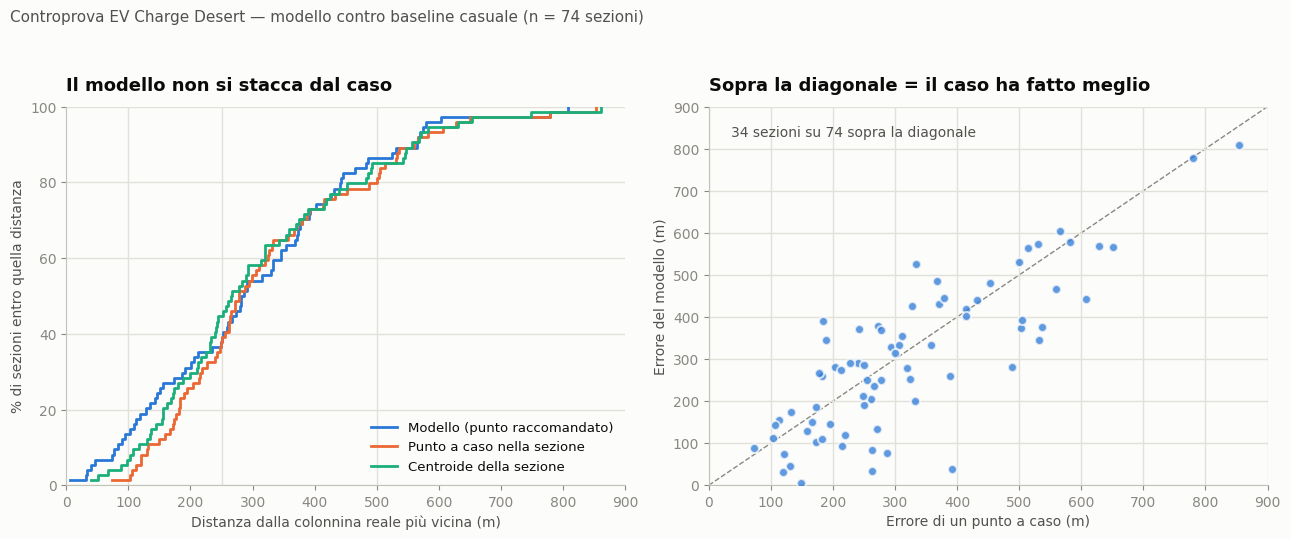

Grafico salvato: validazione_baseline.png


In [15]:
matplotlib.rcParams.update({
    "font.family": "sans-serif", "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
    "text.color": "#0b0b0b", "axes.labelcolor": "#52514e",
    "xtick.color": "#898781", "ytick.color": "#898781", "axes.edgecolor": "#c3c2b7",
})
BLU, ARANCIO, VERDE, GRIGLIA, MUTO = "#2a78d6", "#eb6834", "#1baf7a", "#e1e0d9", "#898781"

fig, (sx, dx) = plt.subplots(1, 2, figsize=(13, 5.4))

def curva(valori):
    v = np.sort(np.asarray(valori))
    return v, np.arange(1, len(v) + 1) / len(v) * 100

for colonna, colore, etichetta in [("modello", BLU, "Modello (punto raccomandato)"),
                                   ("punto_a_caso", ARANCIO, "Punto a caso nella sezione"),
                                   ("centroide", VERDE, "Centroide della sezione")]:
    X, Y = curva(D[colonna])
    sx.step(X, Y, where="post", color=colore, lw=2, label=etichetta)

for s in (100, 250, 500):
    sx.axvline(s, color=GRIGLIA, lw=1, zorder=0)
sx.set_xlim(0, 900); sx.set_ylim(0, 100)
sx.set_xlabel("Distanza dalla colonnina reale più vicina (m)")
sx.set_ylabel("% di sezioni entro quella distanza")
sx.set_title("Il modello non si stacca dal caso", fontsize=13, fontweight="bold",
             color="#0b0b0b", loc="left", pad=12)
sx.legend(frameon=False, loc="lower right", fontsize=9.5)
sx.grid(axis="y", color=GRIGLIA, lw=1); sx.set_axisbelow(True)
for lato in ("top", "right"):
    sx.spines[lato].set_visible(False)

dx.plot([0, 900], [0, 900], color=MUTO, lw=1, ls="--", zorder=0)
dx.scatter(D.punto_a_caso, D.modello, s=42, color=BLU, alpha=.75,
           edgecolor="#fcfcfb", linewidth=1.5, zorder=3)
dx.set_xlim(0, 900); dx.set_ylim(0, 900)
dx.set_xlabel("Errore di un punto a caso (m)")
dx.set_ylabel("Errore del modello (m)")
dx.set_title("Sopra la diagonale = il caso ha fatto meglio", fontsize=13,
             fontweight="bold", color="#0b0b0b", loc="left", pad=12)
dx.text(.04, .95, f"{(D.modello > D.punto_a_caso).sum()} sezioni su {len(D)} sopra la diagonale",
        transform=dx.transAxes, fontsize=10, color="#52514e", va="top")
dx.grid(color=GRIGLIA, lw=1); dx.set_axisbelow(True)
for lato in ("top", "right"):
    dx.spines[lato].set_visible(False)

fig.suptitle(f"Controprova EV Charge Desert — modello contro baseline casuale (n = {len(D)} sezioni)",
             fontsize=11, color="#52514e", y=.99, x=.011, ha="left")
fig.tight_layout(rect=[0, 0, 1, .95])
fig.savefig("validazione_baseline.png", dpi=170, facecolor="#fcfcfb")
plt.show()
print("Grafico salvato: validazione_baseline.png")

In [16]:
# Salviamo la tabella completa, una riga per sezione, per chi vuole controllare
D.round(1).to_csv("risultati_validazione_completi.csv", index=False)
print("Salvato: risultati_validazione_completi.csv")
print(f"\n  Anteprima ({len(D)} righe):")
print(D[["comune", "n_colonnine", "modello", "punto_a_caso", "centroide"]]
      .head(10).round(0).to_string(index=False))

Salvato: risultati_validazione_completi.csv

  Anteprima (74 righe):
                comune  n_colonnine  modello  punto_a_caso  centroide
                Arluno            1    253.0         324.0      293.0
               Basiano            2    779.0         780.0      749.0
               Binasco            4    418.0         415.0      452.0
Boffalora sopra Ticino            2    145.0         195.0      217.0
                Bresso            3     45.0         130.0      118.0
                Bresso            3    346.0         189.0      189.0
              Bubbiano            4    259.0         182.0      168.0
               Bussero            2    574.0         531.0      556.0
           Calvignasco            3      6.0         149.0       89.0
              Cambiago            1    564.0         514.0      492.0


## 10. Conclusioni

**Il modello non può essere considerato validato.** Non perché sbagli, ma perché
**la controprova non è in grado di distinguere** un modello buono da uno inutile.

I tre fatti che lo dimostrano:

1. il modello non batte in modo dimostrabile un punto tirato a caso dentro la stessa
   sezione (p ≈ 0,14), né il centroide (p ≈ 0,63);
2. l'"86% entro 500 metri" è quasi tutto geometria: un punto a caso ottiene circa l'81%,
   e in oltre metà delle sezioni *qualunque* punto rientra nella soglia;
3. il ranking da traffico non ordina: pescare a sorte fra i candidati che il modello ha già
   selezionato dà lo stesso risultato (p ≈ 0,72).

**Cosa resta in piedi, e non è poco:**

- il calcolo di *quante* colonnine servono (818 sezioni critiche) non usa né traffico né POI:
  è una simulazione deterministica sul GAP score e sta in piedi da sola;
- tutta l'infrastruttura dati — 800.000 righe di traffico raccolte in automatico, lo scraping
  POI, l'assegnazione al confine esatto — è lavoro riproducibile e indipendente da questo esito;
- il modello resta uno **strumento di screening** utile: restringe il campo da 13.557 sezioni
  a una lista corta di posti sensati. Non è un selettore di precisione.

**La strada per una validazione vera:** cambiare unità di analisi. Non *"dove dentro la
sezione"* ma *"quali sezioni"* — il modello, ordinando le sezioni per priorità, ne mette in
cima di più fra quelle che hanno poi ricevuto colonnine reali? Si misura con una curva ROC
e si confronta con il caso. È una domanda a cui questi dati possono rispondere.

---

# 11. Cosa dire alla presentazione

> Da qui in poi non c'è codice: è il copione. Le tre slide chiave e le risposte pronte
> alle domande scomode.

## L'idea guida

**Non nascondete il risultato negativo: fatelo diventare il punto di forza.**

Se presentate *"86% entro 500 metri, modello validato"*, la prima persona che chiede
*"e un punto a caso quanto farebbe?"* vi smonta in dieci secondi e non avete risposta.
Se quel numero lo portate voi, la stessa domanda diventa la vostra slide migliore.
È la differenza tra **farsi trovare** un errore e **averlo trovato**.

---

## Le tre slide

### Slide A — "Abbiamo costruito il modello"
Pipeline, dati, criterio di siting in due fasi: prima *dove si può installare* (i POI),
poi *dove c'è domanda* (il traffico).

### Slide B — "Abbiamo fatto la controprova"
Spegniamo le colonnine vere, chiediamo al modello dove metterle, confrontiamo.
**Risultato: 284 m di errore mediano, 86% entro 500 m.** Sembra un buon risultato.

### Slide C — "E poi abbiamo fatto la controprova della controprova"
Ci siamo chiesti se quel numero volesse davvero dire qualcosa. L'abbiamo confrontato con
un punto tirato **a caso** dentro la stessa sezione: **278 m, 81%**. Identico.

Il motivo è geometrico: una sezione di censimento è larga circa 500 metri, e le colonnine
sono state selezionate perché stanno entro 500 metri. **In oltre 40 sezioni su 74 ogni singolo
punto della sezione rientra nella soglia**: quel test non poteva fallire nemmeno volendo.

> Questa è la slide più forte che avete. Dice: non ci siamo accontentati del numero che
> ci faceva comodo.

---

## Come chiamare il modello adesso

Non *"modello che sceglie dove installare"* ma **"strumento di screening che genera siti
candidati"**.

Restringe il campo da 13.557 sezioni a 818 critiche, e dentro quelle propone una lista
corta di posti sensati da andare a verificare. **Questo lo fa.** Quello che non fa —
e lo dite voi per primi — è stabilire quale dei tre sia il migliore: su questo il ranking
da traffico non ha mostrato capacità predittiva.

---

## Cosa vale comunque, e va difeso

| | |
|---|---|
| **Quante colonnine servono** | 818 sezioni, 1-3 colonnine per rientrare sotto soglia. Non usa né traffico né POI: simulazione deterministica sul GAP score. **Sta in piedi da sola.** |
| **L'infrastruttura dati** | 800.000 righe di traffico raccolte in automatico con cadenza adattiva e gestione della quota, scraping POI su 968 sezioni, assegnazione al confine esatto invece che al raggio dal centroide. Ingegneria vera e riproducibile. |
| **L'idea della controprova** | Spegnere le colonnine esistenti e vedere se il modello le ritrova è un disegno intelligente. La maggior parte dei progetti non valida affatto. |

---

## Due errori da evitare

**Non dite "il modello non funziona".** Non è quello che è emerso. È emerso che *il test
non era in grado di distinguere*: la sezione di censimento è un'unità troppo piccola perché
"vicino" significhi qualcosa. Il modello potrebbe funzionare benissimo e questo esperimento
non se ne accorgerebbe.

**Non chiudete sul negativo.** Chiudete con la proposta: cambiare unità di validazione.
Invece di *"dove dentro la sezione"*, chiedere *"quali sezioni"*. Presentata come prossimo
passo, mostra che sapete dove state andando.

---

## Risposte pronte alle domande scomode

**"Quindi avete buttato via il lavoro?"**
No. Il calcolo di quante colonnine servono è intatto e utilizzabile. La pipeline dati è
riutilizzabile. Quello che abbiamo scoperto è che il *test* che avevamo progettato non era
abbastanza sensibile — e lo abbiamo scoperto noi, prima di presentarlo come una certezza.

**"Perché non l'avete fatto giusto da subito?"**
Perché il modello nullo non è un passaggio ovvio: il numero che avevamo (86%) sembrava
convincente, ed è esattamente per questo che va sempre confrontato con un baseline. È la
lezione principale che portiamo a casa da questo progetto.

**"E se rifaceste la raccolta a ottobre, con più traffico?"**
L'abbiamo verificato: la congestione misurata ad agosto non è bassa (47% di rallentamento
al picco, solo il 9% dei candidati sotto 0,2). E nel 62% delle sezioni la congestione si
semplifica dalla formula e non entra nemmeno nella classifica. Un dato migliore non avrebbe
nulla da correggere. Resta possibile che agosto cambi *quali* strade sono trafficate:
si verifica con 48 ore di raccolta a campione in autunno.

**"Il modello è inutile, allora?"**
Come selettore di precisione non abbiamo prove che funzioni. Come strumento di screening sì:
riduce 13.557 sezioni a una lista gestibile e propone punti fisicamente sensati — parcheggi,
distributori, supermercati. Nessuno prima aveva quella lista.